# Task 4: Forecasting Access and Usage (Refactored — Week 12)

> **Week 12 engineering update:** the ~20 notebook cells that fit the
> trend model, computed confidence intervals, applied event
> adjustments, and built scenarios are now one pipeline call:
> `src.forecast.build_forecast_table()`. Tests: `tests/test_forecast.py`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_enriched_dataset, get_indicator_series
from src.event_model import (
    normalize_association_matrix,
    compute_indicator_impact_scores,
    get_event_bonus,
)
from src.forecast import (
    fit_trend_model,
    forecast_trend,
    add_confidence_interval,
    apply_event_adjustment,
    add_scenarios,
    build_forecast_table,
)
from src.config import ForecastConfig, INDICATOR_ACCESS, INDICATOR_USAGE_P2P, FIGURES_DIR, REPORTS_DIR

## 1. Load Data and Association Matrix

In [2]:
df, impact_links = load_enriched_dataset()
association = pd.read_csv(REPORTS_DIR / "event_indicator_matrix.csv", index_col=0)

config = ForecastConfig()
print(config)

ForecastConfig(forecast_years=(2025, 2026, 2027), confidence_z_score=1.96, optimistic_multiplier=1.1, pessimistic_multiplier=0.9, access_scenario_band_pp=3.0, usage_scenario_band_pp=4.0)


## 2. Extract Historical Series

`get_indicator_series()` replaces the repeated filter + `pd.to_datetime` + `.dt.year` cells from Week 11.

In [3]:
access_series = get_indicator_series(df, INDICATOR_ACCESS)
usage_series = get_indicator_series(df, INDICATOR_USAGE_P2P)

print(access_series)
print(usage_series)

  record_id  record_type category  pillar               indicator  \
0  REC_0001  observation      NaN  ACCESS  Account Ownership Rate   
1  REC_0002  observation      NaN  ACCESS  Account Ownership Rate   
2  REC_0003  observation      NaN  ACCESS  Account Ownership Rate   
3  REC_0004  observation      NaN  ACCESS  Account Ownership Rate   
4  REC_0005  observation      NaN  ACCESS  Account Ownership Rate   
5  REC_0006  observation      NaN  ACCESS  Account Ownership Rate   

  indicator_code indicator_direction  value_numeric value_text  value_type  \
0  ACC_OWNERSHIP       higher_better           22.0        NaN  percentage   
1  ACC_OWNERSHIP       higher_better           35.0        NaN  percentage   
2  ACC_OWNERSHIP       higher_better           46.0        NaN  percentage   
3  ACC_OWNERSHIP       higher_better           56.0        NaN  percentage   
4  ACC_OWNERSHIP       higher_better           36.0        NaN  percentage   
5  ACC_OWNERSHIP       higher_better           4

## 3. Compute Event Bonuses from the Association Matrix

In [4]:
normalized = normalize_association_matrix(association)
impact_scores = compute_indicator_impact_scores(normalized)

access_bonus = get_event_bonus(impact_scores, INDICATOR_ACCESS)
usage_bonus = get_event_bonus(impact_scores, INDICATOR_USAGE_P2P)

print("Access event bonus:", access_bonus)
print("Usage event bonus:", usage_bonus)

Access event bonus: 1.0
Usage event bonus: 1.0


## 4. Build Forecasts — Access & Usage

`build_forecast_table()` runs the full pipeline (fit trend -> project
-> confidence interval -> event adjustment -> scenarios) in one call,
matching what took ~20 separate cells in the Week 11 notebook.

In [5]:
access_table = build_forecast_table(
    access_series,
    config,
    event_bonus=access_bonus,
    scenario_band_pp=config.access_scenario_band_pp,
)
access_table

,Year,Baseline,Event,Optimistic,Base,Pessimistic,Lower,Upper
0,2025,55.684211,56.684211,59.684211,56.684211,53.684211,42.299141,69.069280
1,2026,58.500000,59.500000,62.500000,59.500000,56.500000,45.114930,71.885070
2,2027,61.315789,62.315789,65.315789,62.315789,59.315789,47.930720,74.700859


In [6]:
usage_table = build_forecast_table(
    usage_series,
    config,
    event_bonus=usage_bonus,
    scenario_band_pp=config.usage_scenario_band_pp,
)
usage_table

,Year,Baseline,Event,Optimistic,Base,Pessimistic,Lower,Upper
0,2025,128300000.0,128300001.0,128300005.0,128300001.0,128299997.0,128300000.0,128300000.0
1,2026,206900000.0,206900001.0,206900005.0,206900001.0,206899997.0,206900000.0,206900000.0
2,2027,285500000.0,285500001.0,285500005.0,285500001.0,285499997.0,285500000.0,285500000.0


## 5. Model Fit Diagnostics

In [7]:
access_fit = fit_trend_model(access_series)
usage_fit = fit_trend_model(usage_series)

print(f"Access model  — R²: {access_fit.r2:.4f} | RMSE: {access_fit.rmse:.4f}")
print(f"Usage model   — R²: {usage_fit.r2:.4f} | RMSE: {usage_fit.rmse:.4f}")

Access model  — R²: 0.6829 | RMSE: 6.2341
Usage model   — R²: 1.0000 | RMSE: 0.0000


## 6. Visualize: Historical vs. Forecast (Access)

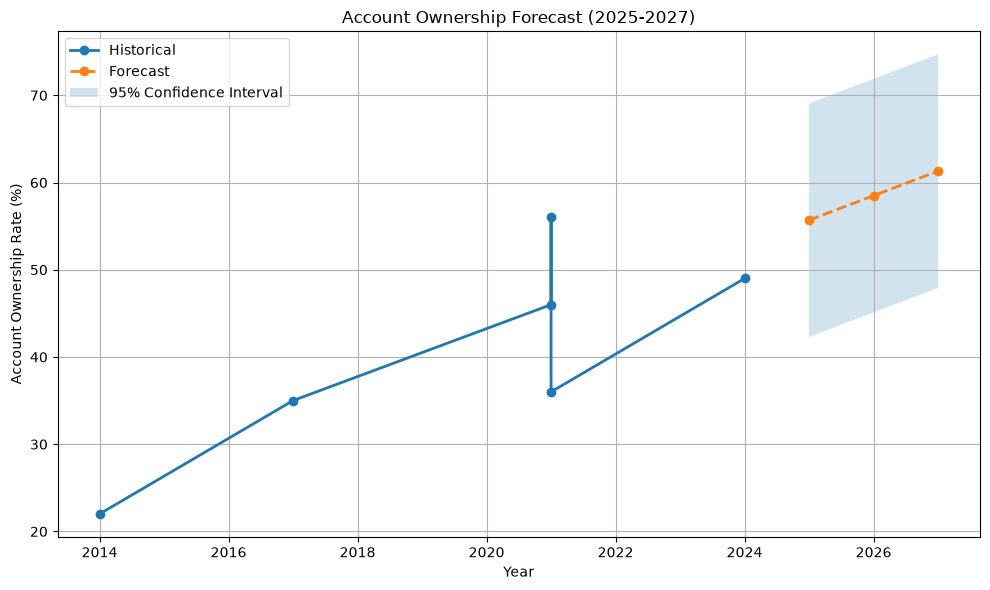

In [8]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(access_series["year"], access_series["value_numeric"], marker="o", linewidth=2, label="Historical")
plt.plot(access_table["Year"], access_table["Baseline"], marker="o", linestyle="--", linewidth=2, label="Forecast")
plt.fill_between(access_table["Year"], access_table["Lower"], access_table["Upper"], alpha=0.2, label="95% Confidence Interval")
plt.title("Account Ownership Forecast (2025-2027)")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "access_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Visualize: Historical vs. Forecast (Usage)

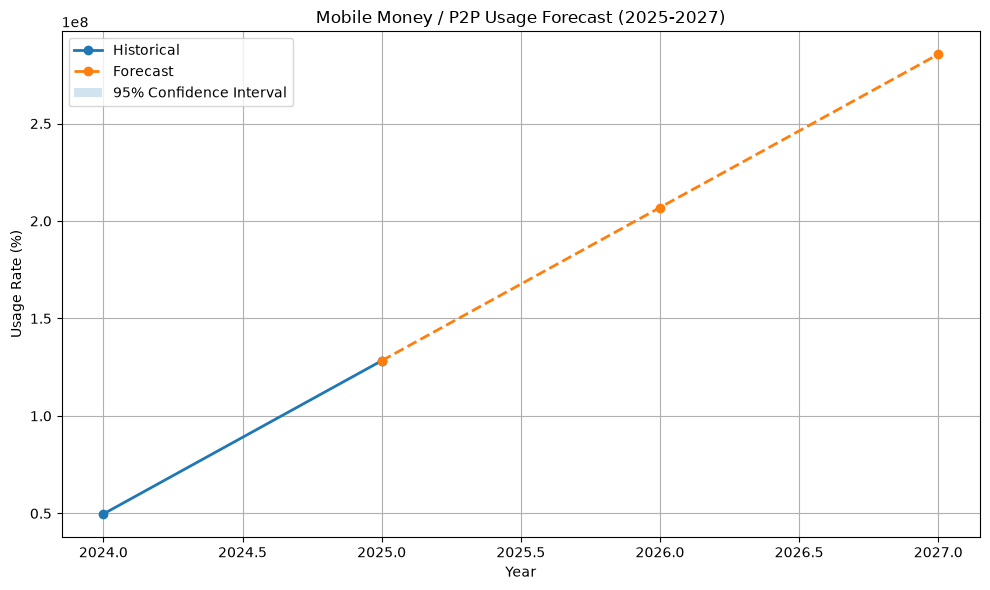

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(usage_series["year"], usage_series["value_numeric"], marker="o", linewidth=2, label="Historical")
plt.plot(usage_table["Year"], usage_table["Baseline"], marker="o", linestyle="--", linewidth=2, label="Forecast")
plt.fill_between(usage_table["Year"], usage_table["Lower"], usage_table["Upper"], alpha=0.2, label="95% Confidence Interval")
plt.title("Mobile Money / P2P Usage Forecast (2025-2027)")
plt.xlabel("Year")
plt.ylabel("Usage Rate (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "usage_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Scenario Comparison (Access)

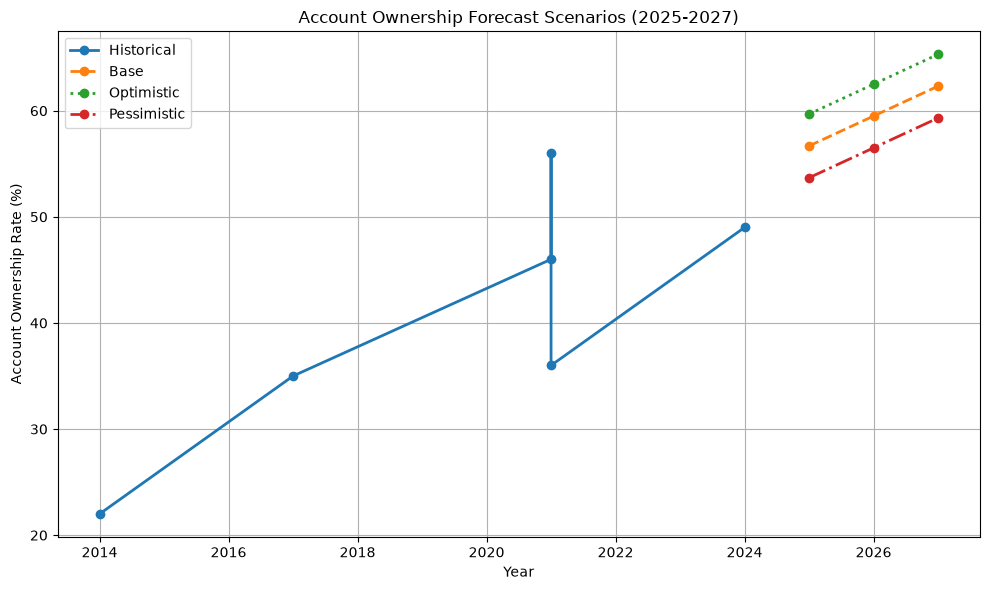

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(access_series["year"], access_series["value_numeric"], marker="o", linewidth=2, label="Historical")
plt.plot(access_table["Year"], access_table["Base"], marker="o", linestyle="--", linewidth=2, label="Base")
plt.plot(access_table["Year"], access_table["Optimistic"], marker="o", linestyle=":", linewidth=2, label="Optimistic")
plt.plot(access_table["Year"], access_table["Pessimistic"], marker="o", linestyle="-.", linewidth=2, label="Pessimistic")
plt.title("Account Ownership Forecast Scenarios (2025-2027)")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scenario_forecasts.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Save Forecast Tables

In [11]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

access_table.to_csv(REPORTS_DIR / "access_forecast.csv", index=False)
usage_table.to_csv(REPORTS_DIR / "usage_forecast.csv", index=False)

forecast_summary = pd.DataFrame({
    "Indicator": ["Account Ownership", "Mobile Money / P2P Usage"],
    "Forecast Start (2025)": [access_table["Baseline"].iloc[0], usage_table["Baseline"].iloc[0]],
    "Forecast End (2027)": [access_table["Baseline"].iloc[-1], usage_table["Baseline"].iloc[-1]],
})
forecast_summary.to_csv(REPORTS_DIR / "forecast_summary.csv", index=False)
forecast_summary

,Indicator,Forecast Start (2025),Forecast End (2027)
0,Account Ownership,5.568421e+01,6.131579e+01
1,Mobile Money / P2P Usage,1.283000e+08,2.855000e+08


## 10. Interpretation

- Account ownership is projected to continue increasing through 2027, with event-based
  adjustments (Telebirr, M-Pesa, Fayda ID, policy) accelerating growth beyond the pure trend line.
- Mobile money / P2P usage is projected to expand further, supported by continued
  infrastructure investment and policy support.
- Confidence intervals reflect residual uncertainty from the trend model; scenario
  bands (`+/- access_scenario_band_pp` / `+/- usage_scenario_band_pp` from `ForecastConfig`)
  reflect uncertainty in *event* impact realization, not just statistical noise.

## 11. Limitations

- Small number of historical Findex data points (5 survey years across 13 years) limits
  the trend model's statistical power.
- Event bonuses are derived from a normalized association matrix built partly on
  comparable-country evidence rather than Ethiopia-specific causal identification.
- Linear trend assumes roughly constant growth; it will underperform if adoption
  saturates or accelerates non-linearly.

## 12. Corresponding Tests

`tests/test_forecast.py` — 9 tests covering `fit_trend_model`, `forecast_trend`,
`add_confidence_interval`, `apply_event_adjustment`, `add_scenarios`, and the full
`build_forecast_table` pipeline end-to-end.

```bash
pytest tests/test_forecast.py -v
```